In [8]:
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from smalldiffusion import (
    TimeInputMLP, ScheduleLogLinear, training_loop, samples,
    DatasaurusDozen, Swissroll
)

In [9]:
def plot_batch(batch):
    batch = batch.cpu().numpy()
    plt.scatter(batch[:,0], batch[:,1], marker='.')

def moving_average(x, w):
    return np.convolve(x, np.ones(w), 'valid') / w

In [10]:
dataset  = Swissroll(np.pi/2, 5*np.pi, 100)

In [11]:
loader   = DataLoader(dataset, batch_size=2048)

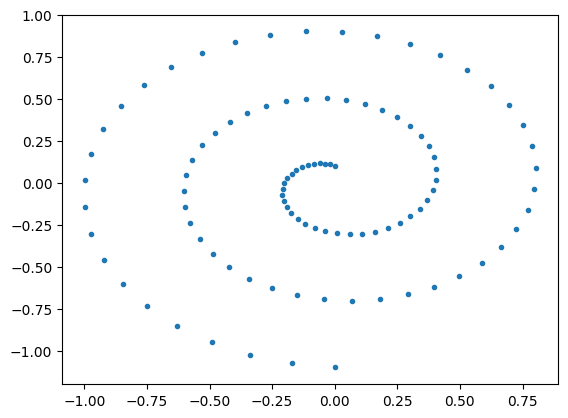

In [12]:
plot_batch(next(iter(loader)))

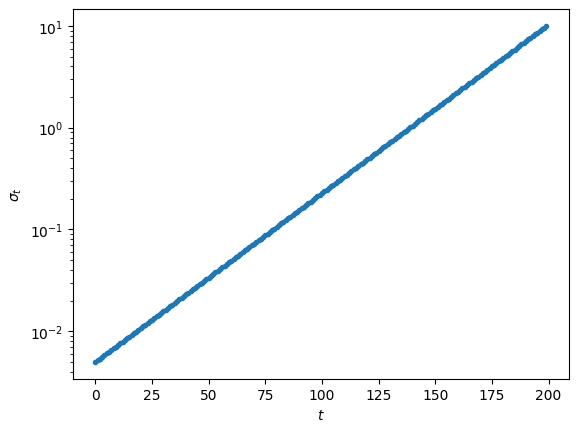

In [15]:
schedule = ScheduleLogLinear(N=200, sigma_min=0.005, sigma_max=10)
plt.plot(schedule.sigmas, marker='.')
plt.xlabel('$t$')
plt.ylabel(r'$\sigma_t$')
plt.yscale('log')

In [16]:
model    = TimeInputMLP(hidden_dims=(16,128,128,128,128,16))
print(model)

TimeInputMLP(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=16, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=16, out_features=128, bias=True)
    (3): GELU(approximate='none')
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): GELU(approximate='none')
    (6): Linear(in_features=128, out_features=128, bias=True)
    (7): GELU(approximate='none')
    (8): Linear(in_features=128, out_features=128, bias=True)
    (9): GELU(approximate='none')
    (10): Linear(in_features=128, out_features=16, bias=True)
    (11): GELU(approximate='none')
    (12): Linear(in_features=16, out_features=2, bias=True)
  )
)


In [17]:
trainer  = training_loop(loader, model, schedule, epochs=15000)

In [18]:
losses = [ns.loss.item() for ns in trainer]

100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 15000/15000 [01:58<00:00, 126.20it/s]


In [21]:
# losses = []
# for i, ns in enumerate(trainer):
#     if (i + 1) % 10 == 0:
#         losses.append(ns.loss.item())
# # losses   = [ns.loss.item() for ns in trainer]

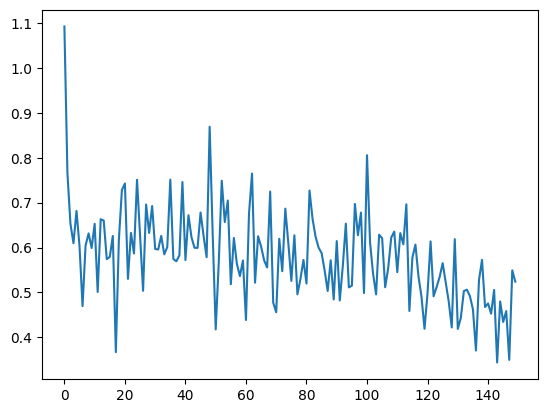

In [24]:
plt.plot(losses[::100])

In [41]:
*xt, x0  = samples(model, schedule.sample_sigmas(20), batchsize=1500, gam=2)

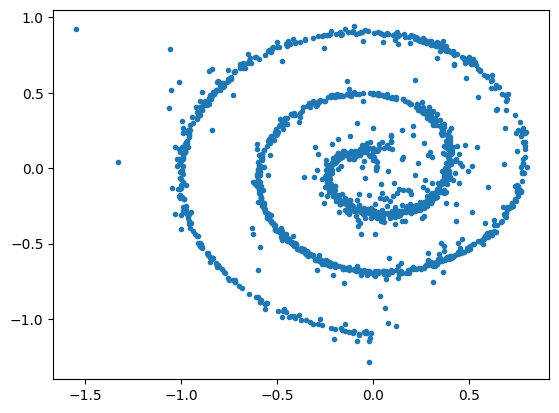

In [42]:
plot_batch(x0)

In [46]:
import torch

In [61]:
xt_np = torch.concat(xt).cpu().detach().numpy()
x0_np = x0.cpu().detach().numpy()

In [62]:
import altair as alt
import matplotlib.pyplot as plt

In [63]:
xt_np

array([[ 0.9793974 , -3.7547855 ],
       [ 0.5344622 , -2.1963382 ],
       [ 0.1854026 , -0.93042684],
       [ 0.10153893, -0.6163974 ],
       [ 0.05191317, -0.49699882],
       [ 0.05609792, -0.4532258 ],
       [ 0.04490078, -0.36987674],
       [ 0.05151278, -0.33035937],
       [ 0.05217177, -0.32323137]], dtype=float32)

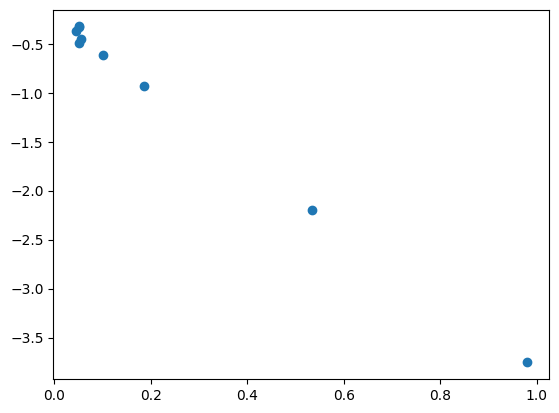

In [64]:
plt.scatter(xt_np[:,0], xt_np[:,1])